# Task 2C (continued) — LLM-as-judge, hallucination review, qualitative analysis
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nazifmhd/Task-1---Financial-AI/blob/main/task2_genai/04_judge_and_review.ipynb)

This notebook consumes the artifacts produced on the GPU by notebooks 02 and 03, which are published
next to the model on the Hugging Face Hub (`training/`, `eval/`), and runs the CPU-only parts of the
evaluation: the LLM judge (Groq), the manual review of the fine-tuned outputs, and the analysis.

In [1]:
# Windows: torch must be imported before scikit-learn, otherwise their OpenMP
# runtimes clash (WinError 1114 loading c10.dll). Harmless elsewhere.
try:
    import torch
except ImportError:
    pass
import os, sys, json, warnings, logging
if os.path.basename(os.getcwd()) != "task2_genai" and os.path.isdir("task2_genai"):
    os.chdir("task2_genai")
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s", force=True)
for n in ("httpx", "openai", "urllib3", "sentence_transformers", "chromadb", "huggingface_hub"):
    logging.getLogger(n).setLevel(logging.WARNING)
import pandas as pd
pd.set_option("display.max_colwidth", 120); pd.set_option("display.width", 200)
from IPython.display import display, Markdown, Image
import config
print("cwd:", os.getcwd())

cwd: E:\CDAZZDEV\Task-1---Financial-AI\task2_genai


In [2]:
# Fetch the GPU-run artifacts from the public model repo if they are not present locally.
from huggingface_hub import hf_hub_download
import shutil
config.OUTPUT_DIR.mkdir(exist_ok=True)
for f in ["eval/metrics.json", "eval/metrics_table.csv", "eval/predictions_base.jsonl",
          "eval/predictions_tuned.jsonl", "eval/rag_results.jsonl", "training/loss_per_epoch.csv",
          "training/loss_curve.png", "training/trainer_log_history.json"]:
    dst = config.OUTPUT_DIR / f.split("/")[-1]
    if not dst.exists():
        shutil.copy(hf_hub_download(config.HF_REPO_ID, f), dst)
print(sorted(p.name for p in config.OUTPUT_DIR.iterdir()))

from src.format_split import load_split
test = load_split("test")
P = lambda name: [json.loads(l) for l in open(config.OUTPUT_DIR / name, encoding="utf-8")]
preds_base, preds_tuned, rag = P("predictions_base.jsonl"), P("predictions_tuned.jsonl"), P("rag_results.jsonl")
metrics = json.load(open(config.OUTPUT_DIR / "metrics.json"))
print("test examples:", len(test), "| model:", f"https://huggingface.co/{config.HF_REPO_ID}")

['diversity.png', 'generation_log.txt', 'judge_log.txt', 'judge_results.jsonl', 'loss_curve.png', 'loss_per_epoch.csv', 'manual_review.json', 'metrics.json', 'metrics_table.csv', 'predictions_base.jsonl', 'predictions_tuned.jsonl', 'rag_results.jsonl', 'trainer_log_history.json']
test examples: 24 | model: https://huggingface.co/nazifmhd/phi3-mini-compliance-extractor


## 1. Recap of the results from notebooks 02 and 03

,epoch,train_loss,val_loss
0,0,NaN,0.4103
1,1,0.2877,0.1836
2,2,0.1788,0.1678
3,3,0.1455,0.1682


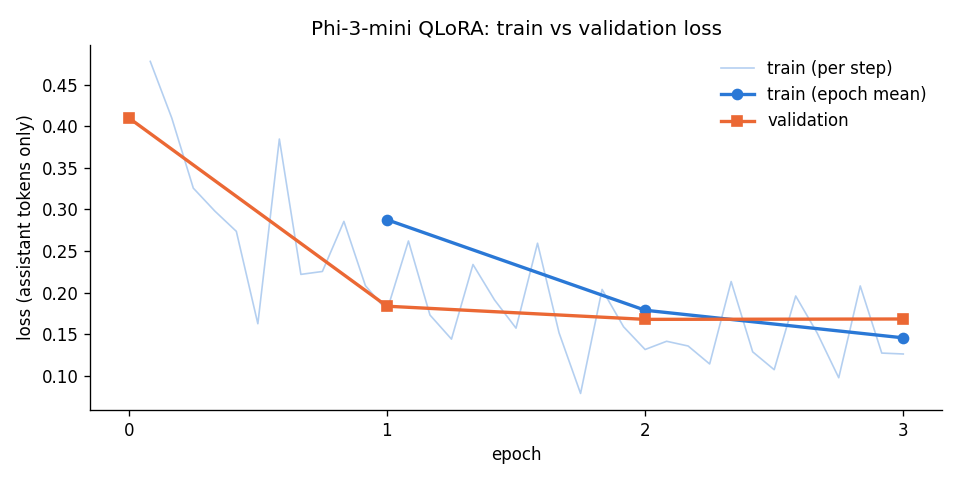

In [3]:
loss = pd.read_csv(config.OUTPUT_DIR / "loss_per_epoch.csv")
display(loss.round(4))
display(Image(filename=str(config.OUTPUT_DIR / "loss_curve.png")))

**Reading the loss curve.** Validation loss falls from 0.410 to 0.184 to 0.168 over epochs 0–2 (−59%),
then is flat at epoch 3 (0.1682, +0.0004, which is within noise for 24 validation examples) while
training loss keeps falling (0.179 → 0.146). That is the onset of over-fitting. Because training used
`load_best_model_at_end` on `eval_loss`, the **epoch-2 checkpoint** is the one that was merged and
published, so the deployed model sits at the minimum of the validation curve. With more time I would
set 2 epochs, or add early stopping with patience 1, rather than rely on checkpoint selection.

In [4]:
table = pd.read_csv(config.OUTPUT_DIR / "metrics_table.csv")
display(Markdown(f"**Base vs fine-tuned on the held-out test set (n = {metrics['n_test']})**"))
display(table.round(3))

**Base vs fine-tuned on the held-out test set (n = 24)**

,metric,base,fine-tuned,Δ,95% CI of Δ (paired bootstrap)
0,ROUGE-L (F),0.633,0.778,0.145,"[+0.094, +0.195]"
1,BERTScore F1,0.905,0.967,0.062,"[+0.054, +0.069]"
2,JSON parse rate,0.792,1.000,0.208,"[+0.083, +0.375]"
3,Schema-valid rate,0.750,1.000,0.250,"[+0.083, +0.417]"
4,clause_type accuracy,0.625,0.917,0.292,"[+0.125, +0.458]"
5,risk_flag accuracy,0.458,0.625,0.167,"[-0.042, +0.375]"
6,party exact match,0.125,0.958,0.833,"[+0.667, +0.958]"
7,trigger null/non-null agreement,0.500,0.708,0.208,"[+0.083, +0.375]"
8,party grounded in clause,0.750,1.000,0.250,"[+0.083, +0.417]"
9,obligation-field ROUGE-L,0.356,0.721,0.365,"[+0.259, +0.473]"


## 2. LLM-as-judge (structured, rubric-based)
The judge (`openai/gpt-oss-120b`, temperature 0) receives the clause, the reference and the candidate.
It returns Pydantic-validated JSON with four 1–5 scores (format, label accuracy, faithfulness,
completeness), a boolean `hallucination` flag and a rationale. Base and fine-tuned outputs are graded
with the identical prompt. **Caveat:** the judge is the same model as the teacher, so it may prefer
teacher-like wording. The rubric therefore treats the *clause*, not the reference, as the source of
truth, and the judge is reported alongside the reference-free structured metrics above.

In [5]:
from src.judge import JUDGE_SYSTEM_PROMPT, judge_all
print(JUDGE_SYSTEM_PROMPT)

You are an expert reviewer grading a model's structured extraction of a financial
contract clause. You receive the CLAUSE, a REFERENCE extraction written by an expert, and a
CANDIDATE extraction produced by a model. Grade the CANDIDATE against the CLAUSE (the source
of truth) and use the REFERENCE as guidance, not as the only acceptable wording.

Score each criterion from 1 (worst) to 5 (best):

- format: 5 = valid JSON with exactly the five required keys and allowed enum values;
  3 = parseable but with extra/missing keys or a non-enum value; 1 = not JSON / unusable.
- label_accuracy: 5 = clause_type and risk_flag both match the reference or are equally
  defensible from the clause; 3 = one of them is wrong; 1 = both wrong.
- faithfulness: 5 = every party, duty, amount, deadline and condition is supported by the
  clause; 3 = minor imprecision but nothing invented; 1 = invents a duty, party or
  condition not in the clause (hallucination).
- completeness: 5 = captures the primary obli

In [6]:
verdicts = judge_all(test, {"base": preds_base, "fine-tuned": preds_tuned})   # cached in outputs/judge_results.jsonl
jv = pd.DataFrame(verdicts)
print("judge errors:", int(jv.get("judge_error", pd.Series(dtype=bool)).fillna(False).sum()))
print("Example structured verdict:"); print(json.dumps(verdicts[-1], indent=1, ensure_ascii=False))
crit = ["format", "label_accuracy", "faithfulness", "completeness"]
summary = jv.groupby("model")[crit].mean()
summary["overall (mean of 4)"] = summary[crit].mean(axis=1)
summary["judge hallucination rate"] = jv.groupby("model")["hallucination"].mean()
display(summary.loc[["base", "fine-tuned"]].round(3))

judge errors: 0
Example structured verdict:
{
 "model": "fine-tuned",
 "id": "ex116",
 "format": 5,
 "label_accuracy": 5,
 "faithfulness": 3,
 "completeness": 3,
 "hallucination": false,
 "rationale": "The candidate correctly labels the clause and risk, and includes the main parties and duty, but omits the required notification within ten business days, making the trigger condition incomplete."
}


,format,label_accuracy,faithfulness,completeness,overall (mean of 4),judge hallucination rate
model,,,,,,
base,4.000,3.667,3.250,3.500,3.604,0.167
fine-tuned,4.917,4.250,3.583,3.917,4.167,0.083


In [7]:
from src.evaluate import bootstrap_diff_ci
piv = jv.assign(overall=jv[crit].mean(axis=1)).pivot(index="id", columns="model", values="overall")
m, lo, hi = bootstrap_diff_ci(piv["base"].tolist(), piv["fine-tuned"].tolist())
print(f"Judge overall score: fine-tuned − base = {m:+.2f} points (95% paired-bootstrap CI [{lo:+.2f}, {hi:+.2f}])")
display(jv[jv.model == "fine-tuned"][["id", *crit, "hallucination", "rationale"]].head(8))

Judge overall score: fine-tuned − base = +0.56 points (95% paired-bootstrap CI [+0.23, +0.90])


,id,format,label_accuracy,faithfulness,completeness,hallucination,rationale
24,ex052,5,3,5,5,False,The JSON is correctly structured and uses allowed enum values; clause_type matches but risk_flag is incorrect; all d...
25,ex072,5,3,3,3,False,"The JSON is well‑formed and uses correct enums, but the risk flag differs from the reference and the obligation omit..."
26,ex214,3,5,3,3,False,"The JSON has the correct keys but uses a non‑standard clause_type value; the party, trigger, and risk flag are corre..."
27,ex165,5,5,3,5,False,"The candidate correctly formats the JSON and matches clause_type and risk_flag, and includes the main parties and tr..."
28,ex111,5,5,5,5,False,"The candidate JSON is well‑formed, correctly labels the clause type and risk, faithfully reflects the duty of the In..."
29,ex000,5,5,5,5,False,"The candidate JSON is correctly structured, matches the reference labels, faithfully reflects the clause without add..."
30,ex114,5,5,5,3,False,"The JSON is correctly structured and matches the clause type and risk flag; it accurately reflects the duty, party, ..."
31,ex024,5,3,3,3,False,The JSON is correctly structured with all required keys; clause_type matches but risk_flag differs from reference. T...


## 3. Manual review of the fine-tuned outputs (hallucination rate)
**All 24** test outputs were reviewed (the brief requires ≥ 10) against the clause text, using the
definitions from notebook 01:
* **correct** — valid JSON, the right `clause_type`, and an obligation, party and trigger that are all supported by the clause;
* **partially correct** — nothing invented, but a wrong `clause_type`/`risk_flag`, an incomplete or secondary obligation, or a missed or confused trigger;
* **hallucinated** — states an obligation, party, amount, deadline or condition that is **not present in the clause**.

Process: a first pass labelled every output. The two outputs that the LLM judge flagged as
hallucinated (`ex008`, `ex098`) were then re-reviewed: `ex008` was relabelled **hallucinated** (a filing
deadline attached to a different duty), and `ex098` stayed *partially correct* (a mis-paraphrase of
"shall not be liable", but no invented fact). The reason for each label is in the table.

In [8]:
review = json.load(open(config.OUTPUT_DIR / "manual_review.json", encoding="utf-8"))
lab = pd.DataFrame(review["labels"])
by_id = {r["id"]: r for r in test}; pt = {p["id"]: p for p in preds_tuned}
lab["clause"] = lab.id.map(lambda i: by_id[i]["messages"][1]["content"])
lab["reference"] = lab.id.map(lambda i: by_id[i]["messages"][2]["content"])
lab["fine-tuned output"] = lab.id.map(lambda i: pt[i]["raw"])
with pd.option_context("display.max_colwidth", None):
    display(lab[["id", "label", "reason", "clause", "fine-tuned output", "reference"]].style
            .set_properties(**{"text-align": "left", "white-space": "pre-wrap", "font-size": "11px"}))

,id,label,reason,clause,fine-tuned output,reference
0,ex052,partially_correct,"Faithful extraction (deadline is in the clause), but risk_flag medium vs reference low.","If a covered loss occurs, the Insured shall pay to the Insurer a deductible of US$5,000 within five Business Days of receiving the claim notice.","{""clause_type"": ""payment_terms"", ""obligation"": ""pay a deductible of US$5,000 within five Business Days of receiving the claim notice"", ""party_responsible"": ""the Insured"", ""trigger_condition"": ""a covered loss occurs"", ""risk_flag"": ""medium""}","{""clause_type"": ""payment_terms"", ""obligation"": ""pay a deductible of US$5,000"", ""party_responsible"": ""the Insured"", ""trigger_condition"": ""If a covered loss occurs"", ""risk_flag"": ""low""}"
1,ex072,partially_correct,Primary duty and party correct; omits the breach-notification duty; risk_flag high vs medium.,"The Borrower shall, at all times during the Term, implement and maintain appropriate technical and organisational measures to protect Personal Data against accidental or unlawful destruction, loss, alteration, unauthorised disclosure or access, in accordance with applicable data‑protection laws of New York, and shall promptly notify the Lender of any breach of such measures.","{""clause_type"": ""data_protection"", ""obligation"": ""implement and maintain appropriate technical and organisational measures to protect Personal Data"", ""party_responsible"": ""the Borrower"", ""trigger_condition"": null, ""risk_flag"": ""high""}","{""clause_type"": ""data_protection"", ""obligation"": ""implement and maintain appropriate technical and organisational measures to protect Personal Data and promptly notify the Lender of any breach"", ""party_responsible"": ""The Borrower"", ""trigger_condition"": null, ""risk_flag"": ""medium""}"
2,ex214,partially_correct,Labelled aml_kyc instead of compliance_covenant. Defensible (the covenant is about AML procedures) but differs from the taxonomy intent; everything else correct.,"The Borrower covenants that, if any Borrower‑initiated transaction under the Syndicated Loan Facility exceeds USD 5,000,000, it shall immediately implement enhanced AML procedures, obtain independent verification of the counter‑party, and submit a detailed AML compliance report to the Administrative Agent within five Business Days, save that such requirement shall not apply to transactions that are expressly permitted under the Exception Schedule attached hereto.","{""clause_type"": ""aml_kyc"", ""obligation"": ""implement enhanced AML procedures, obtain independent verification of the counter‑party, and submit a detailed AML compliance report"", ""party_responsible"": ""the Borrower"", ""trigger_condition"": ""if any Borrower‑initiated transaction under the Syndicated Loan Facility exceeds USD 5,000,000"", ""risk_flag"": ""medium""}","{""clause_type"": ""compliance_covenant"", ""obligation"": ""implement enhanced AML procedures, obtain independent verification and submit a compliance report within five Business Days"", ""party_responsible"": ""The Borrower"", ""trigger_condition"": ""if any Borrower‑initiated transaction under the Syndicated Loan Facility exceeds USD 5,000,000"", ""risk_flag"": ""medium""}"
3,ex165,correct,"Right type, party, trigger and risk; obligation is shorter than the reference but faithful.","THIS LOAN AGREEMENT may be terminated by the Lender Parties upon the occurrence of an Event of Default as defined in Clause 5.1, PROVIDED THAT any such termination shall not apply to amounts already disbursed prior to the default date, SAVE THAT the Borrower shall be entitled to cure such default within ten (10) Business Days after notice thereof, failing which the Lender Parties may give written notice of termination effective immediately thereafter.","{""clause_type"": ""termination"", ""obligation"": ""terminate the loan agreement upon an Event of Default"", ""party_responsible"": ""the Lender Parties"", ""trigger_conditi

In [9]:
counts = lab.label.value_counts().reindex(["correct", "partially_correct", "hallucinated"], fill_value=0)
display(counts.to_frame("n").assign(share=lambda d: (100 * d.n / d.n.sum()).round(1).astype(str) + "%"))
rate = 100 * counts["hallucinated"] / len(lab)
print(f"Hallucination rate (manual review): {rate:.1f}% ({counts['hallucinated']}/{len(lab)} reviewed)")
partial_risk = lab[(lab.label == "partially_correct") & lab.reason.str.contains("risk_flag")]
print(f"Partially-correct outputs whose issues include risk_flag: {len(partial_risk)}/{counts['partially_correct']}")

j = jv[jv.model == "fine-tuned"].set_index("id")["hallucination"]
agree = (lab.set_index("id").label.eq("hallucinated") == j.reindex(lab.id).values).mean()
print(f"Agreement between manual hallucination labels and the LLM judge's flag: {agree:.0%}")
print("Judge hallucination rate — base:", f"{jv[jv.model=='base'].hallucination.mean():.1%}",
      "| fine-tuned:", f"{jv[jv.model=='fine-tuned'].hallucination.mean():.1%}")

,n,share
label,,
correct,12,50.0%
partially_correct,11,45.8%
hallucinated,1,4.2%


Hallucination rate (manual review): 4.2% (1/24 reviewed)
Partially-correct outputs whose issues include risk_flag: 9/11
Agreement between manual hallucination labels and the LLM judge's flag: 96%
Judge hallucination rate — base: 16.7% | fine-tuned: 8.3%


## 4. Before / after examples

In [10]:
from src.schemas import parse_prediction
pb = {p["id"]: p for p in preds_base}
for i in ["ex024", "ex052", "ex217"]:
    _, st_b = parse_prediction(pb[i]["raw"]); _, st_t = parse_prediction(pt[i]["raw"])
    print(f"=== {i}  ({by_id[i]['clause_type']})\nCLAUSE: {by_id[i]['messages'][1]['content']}")
    print(f"\nBASE [{st_b}]:\n{pb[i]['raw']}\n\nFINE-TUNED [{st_t}]:\n{pt[i]['raw']}\n\nREFERENCE:\n{by_id[i]['messages'][2]['content']}\n")

=== ex024  (termination)
CLAUSE: The Client may terminate this Agreement upon thirty (30) days’ written notice if CloudServe Ltd fails to achieve the agreed Service Level Objectives for three consecutive months.

BASE [invalid_json]:
```json
{
  "clause_type": "termination",
  "obligation": "Client has the right to end the agreement if CloudServe Ltd does not meet Service Level Objectives for three months.",
  "party_responsible": "CloudServe Ltd",
Ζ
  "trigger_condition": "Failure to achieve agreed Service Level Objectives for three consecutive months",
  "risk_flag": "medium"
}
```

FINE-TUNED [valid]:
{"clause_type": "termination", "obligation": "terminate the Agreement", "party_responsible": "the Client", "trigger_condition": "CloudServe Ltd fails to achieve the agreed Service Level Objectives for three consecutive months", "risk_flag": "high"}

REFERENCE:
{"clause_type": "termination", "obligation": "Terminate the Agreement upon thirty days' written notice", "party_responsible": "

In [11]:
# Bonus recap: RAG fallback before/after (computed on GPU in notebook 03)
fb = [r for r in rag if r["used_rag"]]
print(f"RAG fallback triggered on {len(fb)}/{len(rag)} test clauses (threshold = val p20 of answer log-prob = {metrics['rag_threshold']:.4f})")
agg_t, agg_r = metrics["tuned"]["aggregate"], metrics["tuned_rag"]["aggregate"]
display(pd.DataFrame({"fine-tuned": agg_t, "fine-tuned + RAG": agg_r}).drop(index="bertscore_f1").round(3))
r = next(x for x in rag if x["id"] == "ex098")
print(f"\n[ex098] confidence {r['first']['mean_logprob']:.3f} < threshold -> retrieved {[h['id'] + ':' + h['clause_type'] for h in r['retrieved']]}")
print("CLAUSE:", by_id["ex098"]["messages"][1]["content"])
print("\nBEFORE:", r["first"]["raw"]); print("AFTER: ", r["final"]["raw"]); print("REF:   ", by_id["ex098"]["messages"][2]["content"])

RAG fallback triggered on 7/24 test clauses (threshold = val p20 of answer log-prob = -0.0891)


,fine-tuned,fine-tuned + RAG
rougeL,0.778,0.775
json_parse,1.000,1.000
schema_valid,1.000,1.000
clause_type_acc,0.917,0.917
risk_flag_acc,0.625,0.542
party_match,0.958,0.958
trigger_null_agree,0.708,0.792
party_in_text,1.000,1.000
obligation_rougeL,0.721,0.716



[ex098] confidence -0.107 < threshold -> retrieved ['ex021:force_majeure', 'ex161:force_majeure', 'ex118:force_majeure']
CLAUSE: Neither Party shall be liable for any failure or delay in performing its obligations under this Agreement to the extent such failure or delay is caused by events beyond its reasonable control, including but not limited to acts of God, war, terrorism, civil unrest, governmental action, or any other force majeure event. Each Party shall promptly notify the other of the occurrence of any such event.

BEFORE: {"clause_type": "force_majeure", "obligation": "limit liability for failure or delay caused by uncontrollable events", "party_responsible": "Neither Party", "trigger_condition": "occurrence of any such event", "risk_flag": "high"}
AFTER:  {"clause_type": "force_majeure", "obligation": "not be liable for any failure or delay in performing its obligations caused by events beyond reasonable control", "party_responsible": "Neither Party", "trigger_condition": "

## 5. Qualitative analysis

**Where fine-tuning helped.**
* **Format.** The largest gain is reliable output. The base model wrapped every answer in a markdown fence and produced unusable JSON on 6/24 clauses. Four of those contain a stray token (`Ζ`) inside the object (`ex024`, `ex098`, `ex220`, `ex034`), and the others invent keys or labels (`"house_flag"` in `ex152`, `"AML_kyc"` in `ex217`). The fine-tuned model returned schema-valid JSON on 24/24.
* **Party extraction.** It learned to copy the party exactly as the clause names it: exact match rose from 12.5% to 95.8%. On `ex052` the base model wrote `"Insured"` where the clause says `"the Insured"`. (Part of that 83-point jump is a convention the model learned, keeping the article. The grounded-in-clause rate rose 75% → 100%, which is the faithfulness part of the gain.)
* **Obligation.** It writes a short, faithful paraphrase instead of a full sentence: obligation-field ROUGE-L 0.36 → 0.72. On `ex164` the base model wrote *"Respondent Bank must remit received funds…"*, while the fine-tuned model returned the reference wording almost verbatim.
* **Labels.** clause_type accuracy rose 62.5% → 91.7%, and the LLM judge's overall score rose 3.60 → 4.17 (format 4.00 → 4.92). Every structural improvement has a 95% paired-bootstrap interval above zero, so the gain is not test-set noise.
* **Robust to teacher errors.** On `ex152` the reference label is a teacher error (`liability_cap` for a duty to give information to a regulator), and the fine-tuned model's `regulatory_reporting` is actually correct.

**Remaining failure modes and next steps.**
* **risk_flag (62.5%) is the weak field,** and its CI includes zero. 9 of the 11 partially-correct outputs differ only or mainly in risk, mostly by one level (`ex077` medium vs low, `ex088` high vs medium). The rubric's thresholds ("material but bounded", "≤ 72 hours") need more contrastive examples than 192 synthetic clauses can supply. The fix is 20–30 human-labelled near-boundary pairs per level and, possibly, a separate classification head or a rule-based check of deadlines and caps.
* **Multi-duty clauses.** The model sometimes merges a condition from one duty into another. `ex008` attaches the filing timeframe to the duty to furnish copies; this is the single hallucination (4.2%). `ex114` puts a deadline in `trigger_condition`. The remedies are (a) training examples with two or three duties whose targets separate them, (b) constrained JSON decoding plus a verification pass that checks each extracted deadline or amount against the clause span it came from, and (c) an explicit `deadline` field so deadlines stop leaking into triggers.
* **Teacher label errors.** QC checks consistency with the generation plan, not semantic correctness, so a mislabelled reference (`ex152`) passed. A small human-validated seed set and agreement filtering between two teacher models would catch these.
* **RAG fallback.** Retrieval triggered on 7/24 clauses and left aggregate quality unchanged (ROUGE-L 0.778 → 0.775). It improved triggers (null/non-null agreement 0.71 → 0.79) and fixed `ex098`'s risk flag, but it also changed correct risk flags (`ex111`). Answer log-probability is a weak correctness signal at this scale. A calibrated confidence model trained on validation errors would route better than a percentile threshold.